In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

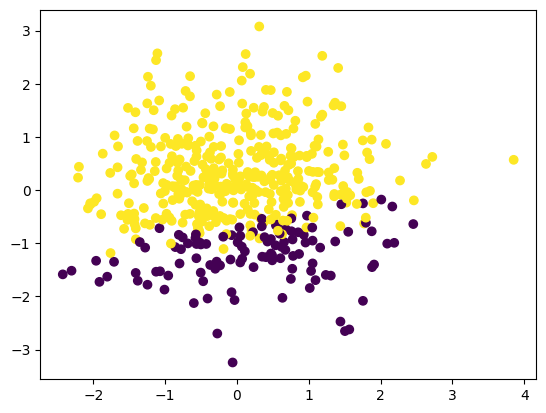

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

## Functions

In [4]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


20. Training loss: 0.9881638457810773, Val loss:0.9645922922843523
40. Training loss: 0.9363184152246646, Val loss:0.9145933994581312
60. Training loss: 0.8881255625797497, Val loss:0.8681824340076577
80. Training loss: 0.8435013650703489, Val loss:0.8252770470945283
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
120. Training loss: 0.76444573392194, Val loss:0.7494732570750171
140. Training loss: 0.7296845906457493, Val loss:0.7162457692441115
160. Training loss: 0.6978459139764438, Val loss:0.6858791790119394
180. Training loss: 0.6687223195489947, Val loss:0.6581659125603253
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
220. Training loss: 0.6177743566104512, Val loss:0.6098530110981566
240. Training loss: 0.5955353995655434, Val loss:0.5888392400909019
260. Training loss: 0.5751907540224198, Val loss:0.569659118137967
280. Training loss: 0.5565584019616943, Val loss:0.5521318211243628
300. Training loss: 0.5394700517290799, Val loss:0.5360

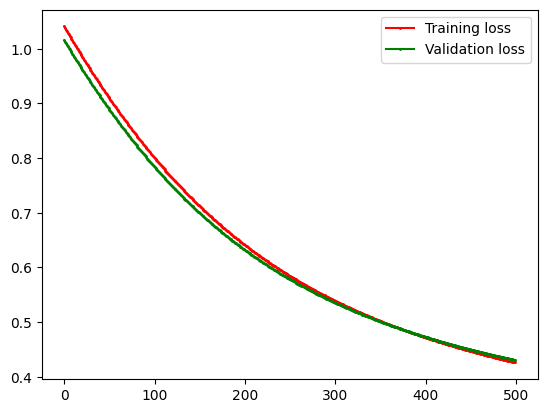

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [6]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


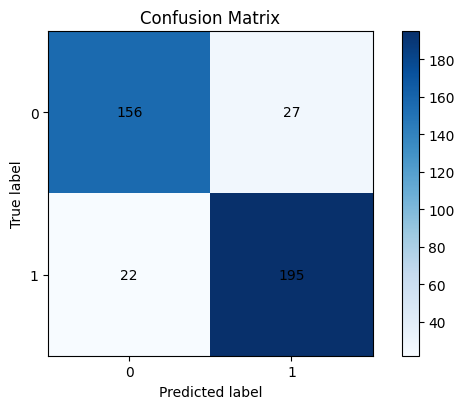

{'Accuracy': 0.8775,
 'Precision': 0.8783783783783784,
 'Recall': 0.8986175115207373,
 'F1-score': 0.8883826879271071}

In [8]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

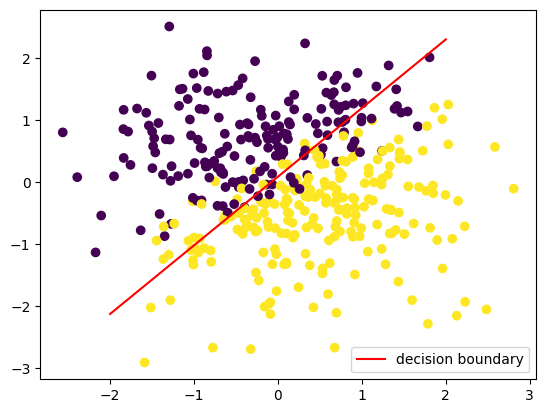

In [ ]:
# Plot
x_min, x_max = X_val[:, 1].min(), X_val[:, 1].max()
y_min, y_max = X_val[:, 2].min(), X_val[:, 2].max()

# Add a small margin so points/boundary are not flush with axes
x_margin = 0.05 * (x_max - x_min)
y_margin = 0.05 * (y_max - y_min)

x_plot_min, x_plot_max = x_min - x_margin, x_max + x_margin
y_plot_min, y_plot_max = y_min - y_margin, y_max + y_margin

plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)

# Decision boundary from model weights: w0 + w1*x1 + w2*x2 = 0
ex1 = np.linspace(x_plot_min, x_plot_max, 200)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.xlim(x_plot_min, x_plot_max)
plt.ylim(y_plot_min, y_plot_max)
plt.legend()
plt.show()